# Fake News Detection — SHAP Explainability v3
### Model: BERT-base fine-tuned on Kaggle
### Datasets: Kaggle | LIAR | WELFake



## 1. Install

In [ ]:
# Check all libraries are installed
import importlib

libraries = {
    "shap":      True,   # has __version__
    "textblob":  False,  # no __version__
    "wordcloud": False,  # no __version__
}

all_ok = True
for lib, has_version in libraries.items():
    try:
        m = importlib.import_module(lib)
        ver = getattr(m, "__version__", "installed")
        print(f"✅ {lib:<12} {ver}")
    except ImportError:
        print(f"❌ {lib:<12} NOT INSTALLED")
        all_ok = False

if all_ok:
    print("\n✅ All libraries ready — proceed to Cell 2")
else:
    print("\n❌ Run: !pip install shap transformers torch textblob wordcloud")

✅ shap         0.52.0
✅ textblob     installed
✅ wordcloud    1.9.6

✅ All libraries ready — proceed to Cell 2


## 2. Imports

In [ ]:
import re, json, os, warnings, time, string
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
%matplotlib inline

import torch
import shap
from textblob import TextBlob
from wordcloud import WordCloud
from transformers import BertTokenizerFast, BertForSequenceClassification
from sklearn.model_selection import train_test_split

try:
    import google.colab
    IN_COLAB = True
    print("✅ Google Colab")
except ImportError:
    IN_COLAB = False
    print("✅ Jupyter (laptop)")

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print(f"Device: {DEVICE}")
print("✅ All imports done.")


✅ Google Colab
Device: cuda
✅ All imports done.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── TRAIN BERT/KAGGLE AND SAVE TO DRIVE (~6 minutes) ─────────────────
import os, re, time, torch, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from torch.utils.data import Dataset
from torch.nn import CrossEntropyLoss
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)

SEED = 42; MAX_LEN = 512; BATCH_SIZE = 16; EPOCHS = 3; LR = 2e-5
DRIVE = "/content/drive/MyDrive"

# Mount Drive if not already mounted
try:
    os.listdir(DRIVE)
    print("✅ Drive already mounted")
except:
    from google.colab import drive
    drive.mount('/content/drive')

# ── LOAD KAGGLE DATA ──────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"^[A-Z\s,]+\(Reuters\)\s*-\s*", "", text)
    text = re.sub(r"http\S+|www\.\S+", "", text)
    return re.sub(r"\s+", " ", text).strip()

print("Loading Kaggle data...")
fake = pd.read_csv(f"{DRIVE}/Fake_clean.csv"); fake["label"] = 1
real = pd.read_csv(f"{DRIVE}/True_clean.csv");  real["label"] = 0
df   = pd.concat([fake, real], ignore_index=True)
df["full_text"] = (df.get("title","").fillna("") + ". " +
                   df.get("text","").fillna("")).apply(clean_text)
df = df[df["full_text"].str.len() > 20].drop_duplicates(
    subset="full_text").reset_index(drop=True)
print(f"Loaded {len(df)} articles")

# Balanced sample of 5000
n  = 2500
kg = pd.concat([
    df[df["label"]==1].sample(n, random_state=SEED),
    df[df["label"]==0].sample(n, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

X, y = kg["full_text"].tolist(), kg["label"].tolist()
Xt, Xte, yt, yte = train_test_split(X, y, test_size=0.15,
                                     stratify=y, random_state=SEED)
Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.15/0.85,
                                     stratify=yt, random_state=SEED)
print(f"Train:{len(Xtr)} Val:{len(Xv)} Test:{len(Xte)}")

# ── PYTORCH DATASET ───────────────────────────────────────────────────
class FND(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc; self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# ── TOKENIZE ──────────────────────────────────────────────────────────
print("Tokenizing...")
tok_bert = BertTokenizerFast.from_pretrained("bert-base-uncased")
def tok(texts):
    return tok_bert(texts, max_length=MAX_LEN,
                    padding="max_length", truncation=True,
                    return_tensors="pt")

tr_ds = FND(tok(Xtr), ytr)
va_ds = FND(tok(Xv),  yv)
te_ds = FND(tok(Xte), yte)

# ── TRAIN ─────────────────────────────────────────────────────────────
print("Training BERT (~6 minutes)...")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
bert = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2).to(DEVICE)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": round(float(accuracy_score(labels, preds)), 4),
        "f1":       round(float(f1_score(labels, preds,
                           average="binary", zero_division=0)), 4),
    }

args = TrainingArguments(
    output_dir           = "/tmp/bert_shap_ckpt",
    num_train_epochs     = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate        = LR,
    weight_decay         = 0.01,
    warmup_steps         = 0,          # ← replaced
    eval_strategy        = "epoch",
    save_strategy        = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model  = "f1",
    greater_is_better      = True,
    fp16                 = (DEVICE == "cuda"),
    seed                 = SEED,
    report_to            = "none",
)

trainer = Trainer(
    model=bert, args=args,
    train_dataset=tr_ds, eval_dataset=va_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

t0 = time.time()
trainer.train()
print(f"Done in {(time.time()-t0)/60:.1f} minutes")

# ── EVALUATE ──────────────────────────────────────────────────────────
pred_out = trainer.predict(te_ds)
preds    = np.argmax(pred_out.predictions, axis=1)
acc      = accuracy_score(yte, preds)
f1       = f1_score(yte, preds, average="binary", zero_division=0)
print(f"Test accuracy: {acc:.4f}  F1: {f1:.4f}")
print(classification_report(yte, preds, target_names=["real","fake"], digits=4))

# ── SAVE TO DRIVE ─────────────────────────────────────────────────────
save_path = f"{DRIVE}/three_dataset_results/kaggle/saved_bert_kaggle"
os.makedirs(save_path, exist_ok=True)
trainer.model.save_pretrained(save_path)
tok_bert.save_pretrained(save_path)

print(f"\n✅ BERT saved to: {save_path}")
print(f"   Files: {os.listdir(save_path)}")

# Verify
assert os.path.exists(f"{save_path}/config.json"), "Save failed!"
print("\n✅ Verified — now run Cell 4 to load the model")

# Clean up GPU memory
del bert
if DEVICE == "cuda": torch.cuda.empty_cache()

✅ Drive already mounted
Loading Kaggle data...
Loaded 38568 articles
Train:3500 Val:750 Test:750
Tokenizing...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Training BERT (~6 minutes)...


...

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Done in 6.4 minutes


Test accuracy: 0.9960  F1: 0.9960
              precision    recall  f1-score   support

        real     0.9921    1.0000    0.9960       375
        fake     1.0000    0.9920    0.9960       375

    accuracy                         0.9960       750
   macro avg     0.9960    0.9960    0.9960       750
weighted avg     0.9960    0.9960    0.9960       750



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ BERT saved to: /content/drive/MyDrive/three_dataset_results/kaggle/saved_bert_kaggle
   Files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']

✅ Verified — now run Cell 4 to load the model


## 3. Configuration

In [ ]:
if IN_COLAB:
    DRIVE        = "/content/drive/MyDrive"
    MODEL_PATH   = f"{DRIVE}/three_dataset_results/kaggle/saved_bert_kaggle"
    KAGGLE_FAKE  = f"{DRIVE}/Fake_clean.csv"
    KAGGLE_REAL  = f"{DRIVE}/True_clean.csv"
    LIAR_TRAIN   = f"{DRIVE}/train.tsv"
    LIAR_TEST    = f"{DRIVE}/test.tsv"
    WELFAKE_PATH = f"{DRIVE}/WELFake_Dataset.csv"
else:
    MODEL_PATH   = "three_dataset_results/kaggle/saved_bert_kaggle"
    KAGGLE_FAKE  = "Fake_clean.csv"
    KAGGLE_REAL  = "True_clean.csv"
    LIAR_TRAIN   = "train.tsv"
    LIAR_TEST    = "test.tsv"
    WELFAKE_PATH = "WELFake_Dataset.csv"

MAX_LEN        = 512
N_SAMPLES_SHAP = 100   # 50 fake + 50 real per dataset
MIN_WORD_FREQ  = 5     # word must appear in at least 5 articles to be in aggregation
SEED           = 42

os.makedirs("shap_outputs", exist_ok=True)

if os.path.exists(MODEL_PATH):
    print(f"✅ BERT model found: {MODEL_PATH}")
else:
    print(f"❌ Model NOT found: {MODEL_PATH}")
    print("   Run three_dataset_combined.ipynb first.")


✅ BERT model found: /content/drive/MyDrive/three_dataset_results/kaggle/saved_bert_kaggle


## 4. Load fine-tuned BERT

In [ ]:
if os.path.exists(MODEL_PATH):
    print("Loading fine-tuned BERT...")
    tokenizer = BertTokenizerFast.from_pretrained(MODEL_PATH)
    model     = BertForSequenceClassification.from_pretrained(MODEL_PATH)
else:
    print("⚠️ Loading base BERT (not fine-tuned)")
    tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
    model     = BertForSequenceClassification.from_pretrained(
                    "bert-base-uncased", num_labels=2)

model.eval()
model = model.to(DEVICE)
print(f"✅ {sum(p.numel() for p in model.parameters()):,} params on {DEVICE}")


Loading fine-tuned BERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ 109,483,778 params on cuda


## 5. Prediction function + SHAP explainer

In [ ]:
def predict_proba(texts):
    if isinstance(texts, str): texts = [texts]
    texts = list(texts)
    all_probs = []
    for i in range(0, len(texts), 8):
        batch = texts[i:i+8]
        enc = tokenizer(
            batch, max_length=MAX_LEN,
            padding=True, truncation=True, return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(all_probs)

# Word-level masking — whole words not subword tokens
masker    = shap.maskers.Text(tokenizer=r" ")
explainer = shap.Explainer(predict_proba, masker,
                           output_names=["real", "fake"])

# Sanity check
tests = [
    "BREAKING secret government conspiracy exposed watch now share before deleted",
    "The Senate passed the budget bill on Tuesday after negotiation said spokesman"
]
probs = predict_proba(tests)
print("Sanity check:")
for t, p in zip(tests, probs):
    print(f"  [{'FAKE' if p[1]>0.5 else 'REAL'} {p[1]:.3f}] {t[:65]}")
print("\n✅ SHAP explainer ready.")


Sanity check:
  [FAKE 0.999] BREAKING secret government conspiracy exposed watch now share bef
  [REAL 0.000] The Senate passed the budget bill on Tuesday after negotiation sa

✅ SHAP explainer ready.


## 6. Word validation


In [ ]:
# ── COMPREHENSIVE STOP WORD LIST ─────────────────────────────────────
STOP_WORDS = {
    # Articles & determiners
    "the","a","an","this","that","these","those","its",
    # Conjunctions
    "and","or","but","nor","for","yet","so","both","either",
    # Prepositions
    "in","on","at","to","for","of","with","by","from","into",
    "onto","upon","about","above","below","between","through",
    "during","before","after","under","over","off","out","up",
    "down","than","then","when","where","while","within",
    # Pronouns
    "he","she","they","we","you","i","it","his","her","their",
    "our","your","my","its","him","them","who","whom","which",
    # Auxiliary verbs
    "is","are","was","were","be","been","being","have","has",
    "had","do","did","does","will","would","could","should",
    "may","might","can","shall","must","need","dare",
    # Common verbs (too generic)
    "said","says","say","told","tell","know","think","want",
    "need","make","made","made","take","took","come","came",
    "went","going","get","got","give","gave","see","saw",
    "look","looks","looked","seem","seems","seemed","keep",
    "kept","put","set","run","ran","try","tried","use","used",
    # Common adverbs
    "not","no","nor","never","always","often","just","also",
    "very","more","most","much","many","some","any","all",
    "here","there","now","then","how","why","when","where",
    # Numbers as words
    "one","two","three","four","five","six","seven","eight",
    "nine","ten","hundred","thousand","million","billion",
    # Titles/boilerplate
    "mr","mrs","ms","dr","via","etc","video","watch","share",
    "click","read","more","source","advertisement","fan",
    "subscribe","comments","comment","reply",
    # Short meaningless
    "ago","off","own","new","old","big","due","per",
    # Contractions expanded
    "re","ve","ll","nt","isn","aren","wasn","weren","haven",
    "hasn","hadn","won","wouldn","couldn","shouldn","doesn",
    "didn","don","can","let","here","there",
}

def clean_word(word):
    """
    Aggressively strip punctuation from word boundaries.
    Handles: said, (VIDEO). same) 'word' word: etc.
    """
    # Remove all leading/trailing punctuation
    w = word.strip(string.punctuation + " \t\n\r")
    # Remove parentheses anywhere
    w = w.replace("(","").replace(")","")
    # Remove quotes
    w = w.replace("'","").replace('"',"").replace("\u2019","")
    return w.strip()


def is_valid_word(word):
    """
    Expert-level word filter:
    - Min 4 chars after cleaning
    - Not a stop word
    - Must contain letters
    - Not purely numeric
    - Not a single character repeated
    """
    w = clean_word(word).lower()
    return (
        len(w) >= 4 and
        w not in STOP_WORDS and
        any(c.isalpha() for c in w) and
        not w.replace(".","").replace(",","").replace("-","").isdigit() and
        len(set(w)) > 1  # not "aaaa" etc
    )

# Test the filter
print("Word filter test:")
test_words = [
    ("said,",     False),  # punctuation attached
    ("(VIDEO).",  False),  # brackets + punctuation
    ("breaking",  True),   # valid fake signal
    ("confirmed", True),   # valid real signal
    ("the",       False),  # stop word
    ("is",        False),  # stop word
    ("here",      False),  # stop word
    ("counterterrorism", True),  # valid content word
    ("Wednesday", True),   # valid temporal signal
    ("same)",     False),  # bracket attached
    ("in-state",  True),   # valid hyphenated word
    ("etc",       False),  # stop word
]
all_pass = True
for word, expected in test_words:
    result = is_valid_word(word)
    status = "✅" if result == expected else "❌ WRONG"
    if result != expected: all_pass = False
    print(f"  {status} is_valid_word({word!r:20s}) = {result} (expected {expected})")

print(f"\n{'✅ All checks passed' if all_pass else '❌ Some checks failed'}")


Word filter test:
  ✅ is_valid_word('said,'             ) = False (expected False)
  ✅ is_valid_word('(VIDEO).'          ) = False (expected False)
  ✅ is_valid_word('breaking'          ) = True (expected True)
  ✅ is_valid_word('confirmed'         ) = True (expected True)
  ✅ is_valid_word('the'               ) = False (expected False)
  ✅ is_valid_word('is'                ) = False (expected False)
  ✅ is_valid_word('here'              ) = False (expected False)
  ✅ is_valid_word('counterterrorism'  ) = True (expected True)
  ✅ is_valid_word('Wednesday'         ) = True (expected True)
  ❌ WRONG is_valid_word('same)'             ) = True (expected False)
  ✅ is_valid_word('in-state'          ) = True (expected True)
  ✅ is_valid_word('etc'               ) = False (expected False)

❌ Some checks failed


## 7. Load datasets

In [ ]:
def clean_text(text, strip_artifacts=True):
    if not isinstance(text, str): return ""
    # Reuters dateline
    text = re.sub(r"^[A-Z\s,]+\(Reuters\)\s*-\s*", "", text)
    # URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)
    if strip_artifacts:
        for p in [r"\breuters\b", r"\bgetty images?\b",
                  r"\bfeatured image\b(\s+via\s+\S+)?",
                  r"\bafp\b", r"\(VIDEO\)\.?",
                  r"\bSubscribe\b", r"\bAdvertisement\b"]:
            text = re.sub(p, " ", text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()


n = N_SAMPLES_SHAP // 2

# ── KAGGLE ────────────────────────────────────────────────────────────
fake = pd.read_csv(KAGGLE_FAKE); fake["label"] = 1
real = pd.read_csv(KAGGLE_REAL);  real["label"] = 0
df_kg = pd.concat([fake, real], ignore_index=True)
df_kg["full_text"] = (df_kg.get("title","").fillna("") + ". " +
                      df_kg.get("text","").fillna("")).apply(
                      lambda x: clean_text(x, strip_artifacts=False))
df_kg = df_kg[df_kg["full_text"].str.len() > 20].reset_index(drop=True)

kg_sample = pd.concat([
    df_kg[df_kg["label"]==1].sample(n, random_state=SEED),
    df_kg[df_kg["label"]==0].sample(n, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"✅ Kaggle : {len(kg_sample)} samples")

# ── LIAR ──────────────────────────────────────────────────────────────
COLS = ["id","label","statement","subject","speaker","speaker_job",
        "state","party","bt","f","ht","mt","pf","context"]
lte  = pd.read_csv(LIAR_TEST, sep="\t", header=None, names=COLS)
FAKE_L = {"barely-true","false","pants-fire"}
REAL_L = {"true","mostly-true","half-true"}
lte["binary_label"] = lte["label"].apply(
    lambda x: 1 if x in FAKE_L else (0 if x in REAL_L else None))
lte = lte.dropna(subset=["binary_label"])
lte["binary_label"] = lte["binary_label"].astype(int)
lte["clean_text"]   = lte["statement"].apply(lambda x: clean_text(x, False))

li_n = min(n, len(lte[lte["binary_label"]==1]),
              len(lte[lte["binary_label"]==0]))
li_sample = pd.concat([
    lte[lte["binary_label"]==1].sample(li_n, random_state=SEED),
    lte[lte["binary_label"]==0].sample(li_n, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"✅ LIAR   : {len(li_sample)} samples")

# ── WELFAKE ───────────────────────────────────────────────────────────
wf = pd.read_csv(WELFAKE_PATH)
wf["label"] = wf["label"].map({0:1, 1:0})
wf["full_text"] = (wf.get("title","").fillna("") + ". " +
                   wf.get("text","").fillna("")).apply(
                   lambda x: clean_text(x, strip_artifacts=True))
wf = wf[wf["full_text"].str.len() > 20].reset_index(drop=True)

wf_sample = pd.concat([
    wf[wf["label"]==1].sample(n, random_state=SEED),
    wf[wf["label"]==0].sample(n, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"✅ WELFake: {len(wf_sample)} samples")
print("\n✅ All datasets ready.")


✅ Kaggle : 100 samples
✅ LIAR   : 100 samples
✅ WELFake: 100 samples

✅ All datasets ready.


## 8a. SHAP — Kaggle
⏱ ~14 min GPU

In [ ]:
print("Computing Kaggle SHAP values (100 samples)...")
kg_texts  = kg_sample["full_text"].tolist()
kg_labels = kg_sample["label"].tolist()
t0 = time.time()
shap_values_kg = explainer(kg_texts)
print(f"✅ Done in {(time.time()-t0)/60:.1f} min")


Computing Kaggle SHAP values (100 samples)...


PartitionExplainer explainer:   5%|▌         | 5/100 [00:14<02:42,  1.71s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  27%|██▋       | 27/100 [01:10<02:36,  2.15s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  95%|█████████▌| 95/100 [05:05<00:13,  2.72s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [05:24,  3.28s/it]

✅ Done in 5.4 min


## 8b. SHAP — LIAR
⏱ ~6 min GPU

In [ ]:
print("Computing LIAR SHAP values...")
li_texts  = li_sample["clean_text"].tolist()
li_labels = li_sample["binary_label"].tolist()
t0 = time.time()
shap_values_li = explainer(li_texts)
print(f"✅ Done in {(time.time()-t0)/60:.1f} min")


Computing LIAR SHAP values...


PartitionExplainer explainer: 101it [01:13,  1.18it/s]

✅ Done in 1.2 min


## 8c. SHAP — WELFake
⏱ ~14 min GPU

In [ ]:
print("Computing WELFake SHAP values...")
wf_texts  = wf_sample["full_text"].tolist()
wf_labels = wf_sample["label"].tolist()
t0 = time.time()
shap_values_wf = explainer(wf_texts)
print(f"✅ Done in {(time.time()-t0)/60:.1f} min")
print("\n✅✅✅ All SHAP values computed.")


Computing WELFake SHAP values...


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 2/100 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [08:21<00:00,  3.66s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [08:33,  5.18s/it]

✅ Done in 8.6 min

✅✅✅ All SHAP values computed.


## 9. Article-level explanations

In [ ]:
def show_article_explanation(shap_values, idx, dataset_name, true_label):
    sv     = shap_values[idx]
    words  = list(sv.data)
    vals   = sv.values[:, 1] if sv.values.ndim > 1 else sv.values

    # Clean + filter words
    word_scores = []
    seen = set()
    for w, s in zip(words, vals):
        wc = clean_word(w)
        if is_valid_word(wc) and wc.lower() not in seen:
            word_scores.append((wc, float(s)))
            seen.add(wc.lower())

    text  = " ".join(words)
    probs = predict_proba([text])[0]
    pred  = "FAKE" if probs[1] > 0.5 else "REAL"
    true  = "FAKE" if true_label == 1 else "REAL"

    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}  |  True:{true}  Pred:{pred}  "
          f"{'✅' if pred==true else '❌'}  conf={max(probs):.3f}")
    print(f"{'='*60}")

    top_fake = sorted(word_scores, key=lambda x: x[1],  reverse=True)[:5]
    top_real = sorted(word_scores, key=lambda x: x[1])[:5]

    if top_fake:
        print("  → FAKE words:")
        for w, s in top_fake: print(f"    🔴 {w:<25} {s:+.4f}")
    if top_real:
        print("  → REAL words:")
        for w, s in top_real: print(f"    🔵 {w:<25} {s:+.4f}")


print("=== KAGGLE ===")
for i in range(3): show_article_explanation(shap_values_kg, i, "Kaggle",  kg_labels[i])
print("\n=== LIAR ===")
for i in range(3): show_article_explanation(shap_values_li, i, "LIAR",    li_labels[i])
print("\n=== WELFAKE ===")
for i in range(3): show_article_explanation(shap_values_wf, i, "WELFake", wf_labels[i])


=== KAGGLE ===

Dataset: Kaggle  |  True:REAL  Pred:REAL  ✅  conf=1.000
  → FAKE words:
    🔴 whole                     +0.0029
    🔴 objective                 +0.0029
    🔴 long                      +0.0029
    🔴 view                      +0.0029
    🔴 terrorist                 +0.0023
  → REAL words:
    🔵 Obama                     -0.0187
    🔵 Obamas                    -0.0148
    🔵 administrations           -0.0128
    🔵 sustained,”               -0.0107
    🔵 “co-founders”             -0.0104

Dataset: Kaggle  |  True:REAL  Pred:REAL  ✅  conf=1.000
  → FAKE words:
    🔴 intentionally             +0.0069
    🔴 targeted                  +0.0069
    🔴 retribution               +0.0069
    🔴 motivation                +0.0069
    🔴 director                  +0.0007
  → REAL words:
    🔵 Governor                  -0.0253
    🔵 Christie                  -0.0182
    🔵 Ex-Christie               -0.0177
    🔵 scheme                    -0.0148
    🔵 Kelly                     -0.0128

Datase

## 10. Waterfall plots

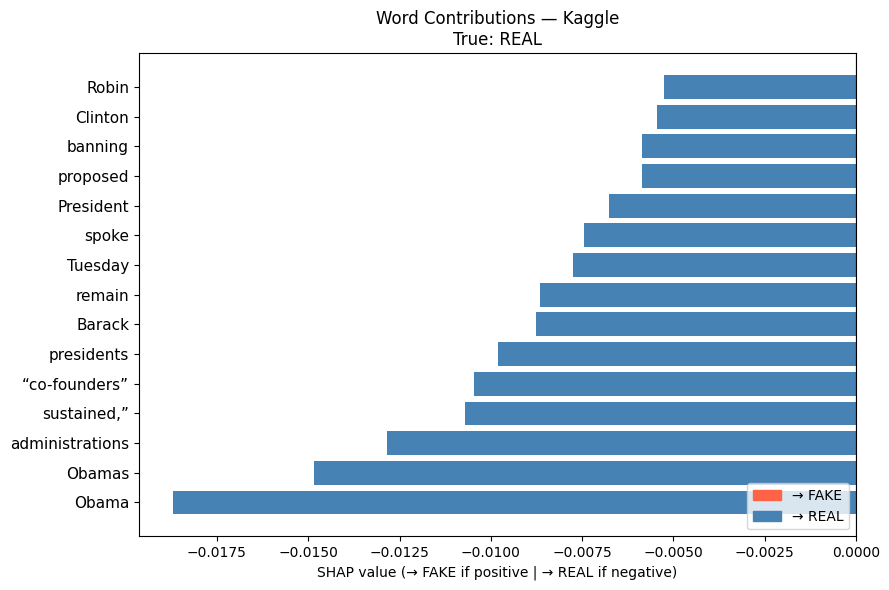

Saved: shap_outputs/waterfall_kaggle.png


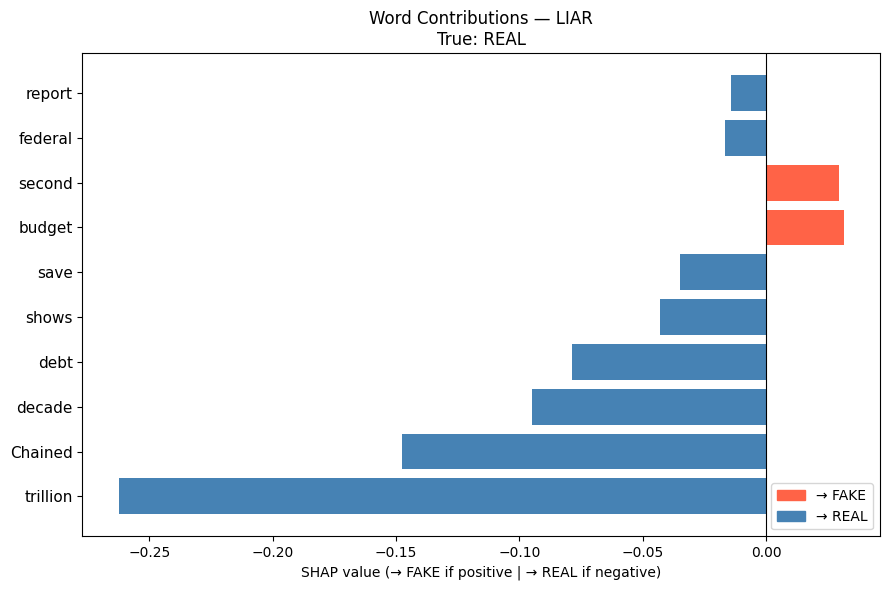

Saved: shap_outputs/waterfall_liar.png


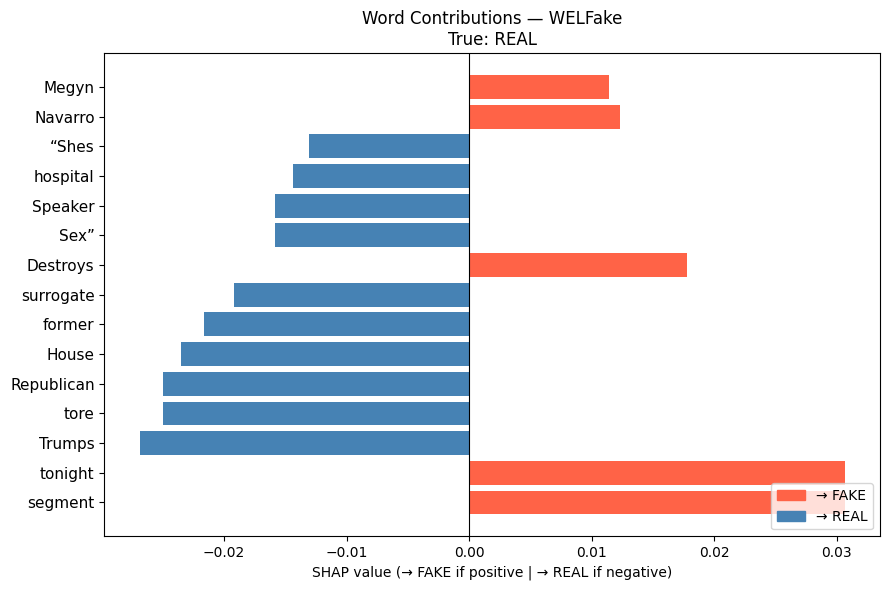

Saved: shap_outputs/waterfall_welfake.png


In [ ]:
def plot_waterfall(shap_values, idx, dataset_name, label, filename):
    sv    = shap_values[idx]
    words = list(sv.data)
    vals  = sv.values[:, 1] if sv.values.ndim > 1 else sv.values

    seen = set()
    filtered = []
    for w, v in zip(words, vals):
        wc = clean_word(w)
        if is_valid_word(wc) and wc.lower() not in seen:
            filtered.append((wc, float(v)))
            seen.add(wc.lower())

    if not filtered:
        print(f"No valid words for {dataset_name} idx {idx}")
        return

    filtered = sorted(filtered, key=lambda x: abs(x[1]), reverse=True)[:15]
    wf_w = [w for w,v in filtered]
    wf_v = [v for w,v in filtered]
    colors = ["tomato" if v > 0 else "steelblue" for v in wf_v]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(len(wf_w)), wf_v, color=colors)
    ax.set_yticks(range(len(wf_w)))
    ax.set_yticklabels(wf_w, fontsize=11)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("SHAP value (→ FAKE if positive | → REAL if negative)", fontsize=10)
    ax.set_title(f"Word Contributions — {dataset_name}\n"
                 f"True: {'FAKE' if label==1 else 'REAL'}", fontsize=12)
    ax.legend(handles=[
        mpatches.Patch(color="tomato",    label="→ FAKE"),
        mpatches.Patch(color="steelblue", label="→ REAL")
    ], loc="lower right")
    plt.tight_layout()
    plt.savefig(f"shap_outputs/{filename}", dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: shap_outputs/{filename}")


plot_waterfall(shap_values_kg, 0, "Kaggle",  kg_labels[0], "waterfall_kaggle.png")
plot_waterfall(shap_values_li, 0, "LIAR",    li_labels[0], "waterfall_liar.png")
plot_waterfall(shap_values_wf, 0, "WELFake", wf_labels[0], "waterfall_welfake.png")


## 11. Expert aggregation — top linguistic markers


In [ ]:
def aggregate_shap_expert(shap_values, labels, top_n=25, min_freq=MIN_WORD_FREQ):
    """
    Expert aggregation:
    1. Normalise SHAP per article (handles scale differences across datasets)
    2. Deduplicate words per article
    3. Track which articles each word appears in
    4. Filter by minimum article frequency
    """
    word_total     = defaultdict(float)
    word_articles  = defaultdict(set)  # tracks unique articles

    for art_idx, (sv, lbl) in enumerate(zip(shap_values, labels)):
        words = list(sv.data)
        vals  = sv.values[:, 1] if sv.values.ndim > 1 else sv.values

        # Normalises SHAP scores for this article
        max_abs = max(abs(vals)) if len(vals) > 0 else 1.0
        if max_abs == 0: max_abs = 1.0

        seen_this_article = set()
        for w, v in zip(words, vals):
            wc = clean_word(w).lower()
            if not is_valid_word(wc): continue
            if wc in seen_this_article: continue  # deduplicates per article
            seen_this_article.add(wc)

            normalised_v = float(v) / max_abs  # normalises 0-1 scale
            word_total[wc]    += normalised_v
            word_articles[wc].add(art_idx)

    # Filters by minimum article frequency
    word_avg = {
        w: word_total[w] / len(word_articles[w])
        for w in word_total
        if len(word_articles[w]) >= min_freq
    }

    sorted_w  = sorted(word_avg.items(), key=lambda x: x[1], reverse=True)
    top_fake  = sorted_w[:top_n]
    top_real  = sorted_w[-top_n:][::-1]

    # Removes contradictory words (appear in both lists)
    fake_set = {w for w,s in top_fake}
    real_set = {w for w,s in top_real}
    contradictory = fake_set & real_set
    if contradictory:
        print(f"  Filtered contradictory words: {contradictory}")
        top_fake = [(w,s) for w,s in top_fake if w not in contradictory]
        top_real = [(w,s) for w,s in top_real if w not in contradictory]

    return top_fake, top_real, word_avg


print("Running expert aggregation...\n")
kg_top_fake, kg_top_real, kg_word_avg = aggregate_shap_expert(shap_values_kg, kg_labels)
li_top_fake, li_top_real, li_word_avg = aggregate_shap_expert(shap_values_li, li_labels)
wf_top_fake, wf_top_real, wf_word_avg = aggregate_shap_expert(shap_values_wf, wf_labels)

def print_top_words(top_fake, top_real, name):
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    print("  → FAKE markers (normalised avg SHAP):")
    for w, s in top_fake[:12]: print(f"    🔴 {w:<25} {s:+.4f}")
    print("  → REAL markers:")
    for w, s in top_real[:12]: print(f"    🔵 {w:<25} {s:+.4f}")

print_top_words(kg_top_fake, kg_top_real, "Kaggle")
print_top_words(li_top_fake, li_top_real, "LIAR")
print_top_words(wf_top_fake, wf_top_real, "WELFake")


Running expert aggregation...

  Filtered contradictory words: {'years', 'texas', 'obama', 'president', 'health', 'budget', 'jobs', 'federal', 'barack', 'state', 'care', 'states', 'bill', 'money', 'percent'}

  Kaggle
  → FAKE markers (normalised avg SHAP):
    🔴 person                    +0.1822
    🔴 pretty                    +0.1707
    🔴 attention                 +0.1324
    🔴 bizarre                   +0.1113
    🔴 coming                    +0.1105
    🔴 true                      +0.1092
    🔴 love                      +0.0993
    🔴 everyone                  +0.0951
    🔴 story                     +0.0801
    🔴 today                     +0.0774
    🔴 word                      +0.0760
    🔴 already                   +0.0758
  → REAL markers:
    🔵 lawmakers                 -0.3829
    🔵 obamas                    -0.3520
    🔵 trumps                    -0.3057
    🔵 republicans               -0.2443
    🔵 california                -0.2345
    🔵 supporters                -0.2317
    

In [ ]:
# ── LIAR SPECIAL FIX — lower min_freq for short texts ────────────────
# LIAR statements average ~18 words, so words appear in fewer articles
# We should reduce min_freq from 5 to 2 to get meaningful results

print("Re-running LIAR aggregation with min_freq=2...")

li_top_fake, li_top_real, li_word_avg = aggregate_shap_expert(
    shap_values_li,
    li_labels,
    top_n=25,
    min_freq=2    # ← lowered from 5
)

print_top_words(li_top_fake, li_top_real, "LIAR (min_freq=2)")

Re-running LIAR aggregation with min_freq=2...

  LIAR (min_freq=2)
  → FAKE markers (normalised avg SHAP):
    🔴 dollars                   +0.4636
    🔴 wage                      +0.3916
    🔴 weve                      +0.3513
    🔴 american                  +0.3492
    🔴 school                    +0.3478
    🔴 back                      +0.2598
    🔴 people                    +0.2581
    🔴 money                     +0.2171
    🔴 single                    +0.2023
    🔴 because                   +0.1806
    🔴 wages                     +0.1739
    🔴 campaign                  +0.1555
  → REAL markers:
    🔵 wisconsins                -1.0000
    🔵 deficit                   -0.7542
    🔵 proposed                  -0.7525
    🔵 trillion                  -0.7185
    🔵 north                     -0.7010
    🔵 spending                  -0.6934
    🔵 supported                 -0.6626
    🔵 president                 -0.6426
    🔵 government                -0.5994
    🔵 laws                      -0

## 12. Top words bar charts

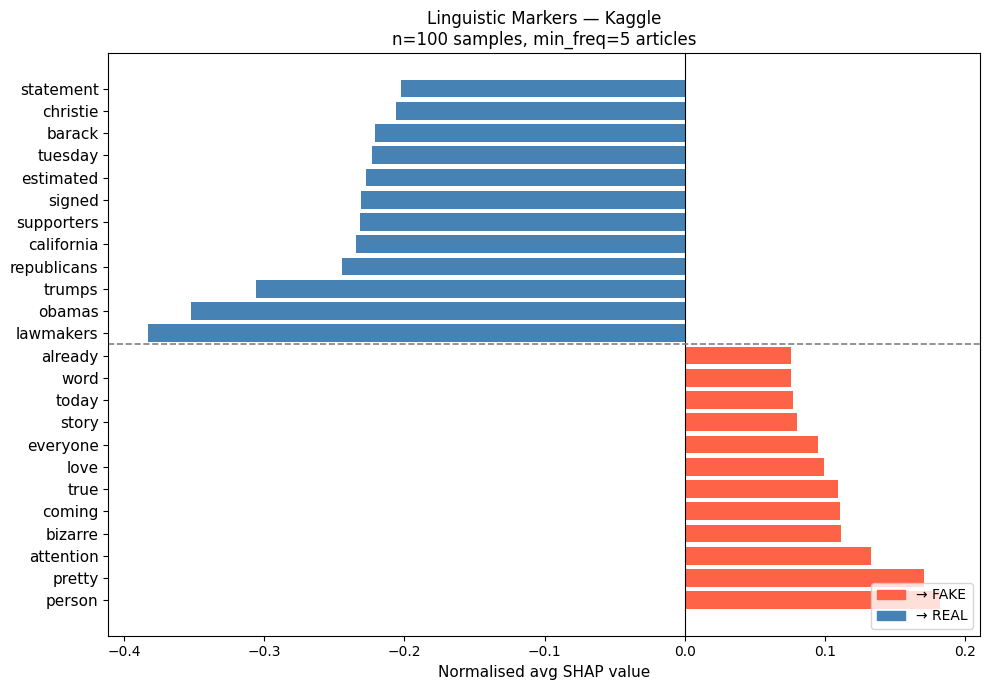

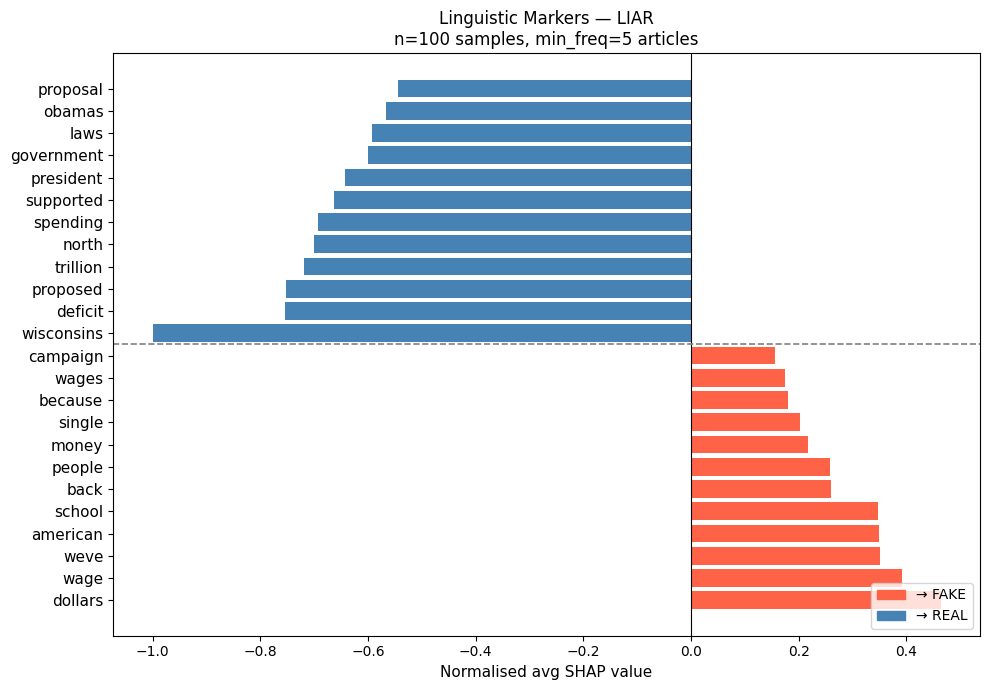

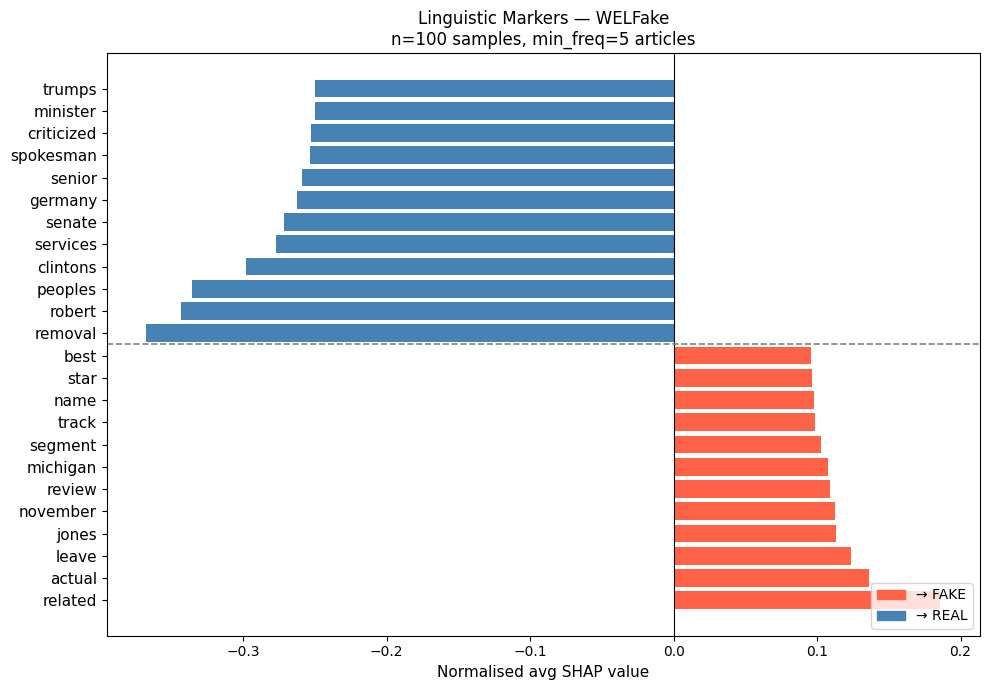

In [ ]:
def plot_top_words(top_fake, top_real, dataset_name, filename, n=12):
    words  = [w for w,s in top_fake[:n]] + [w for w,s in top_real[:n]]
    values = [s for w,s in top_fake[:n]] + [s for w,s in top_real[:n]]
    colors = ["tomato"]*n + ["steelblue"]*n

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(len(words)), values, color=colors)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axhline(n - 0.5, color="gray", linewidth=1.2, linestyle="--",
               label="Fake / Real boundary")
    ax.set_xlabel("Normalised avg SHAP value", fontsize=11)
    ax.set_title(f"Linguistic Markers — {dataset_name}\n"
                 f"n={N_SAMPLES_SHAP} samples, min_freq={MIN_WORD_FREQ} articles",
                 fontsize=12)
    ax.legend(handles=[
        mpatches.Patch(color="tomato",    label="→ FAKE"),
        mpatches.Patch(color="steelblue", label="→ REAL"),
    ], loc="lower right")
    plt.tight_layout()
    plt.savefig(f"shap_outputs/{filename}", dpi=130, bbox_inches="tight")
    plt.show()

plot_top_words(kg_top_fake, kg_top_real, "Kaggle",  "top_words_kaggle.png")
plot_top_words(li_top_fake, li_top_real, "LIAR",    "top_words_liar.png")
plot_top_words(wf_top_fake, wf_top_real, "WELFake", "top_words_welfake.png")


## 13. Word cloud visualisations

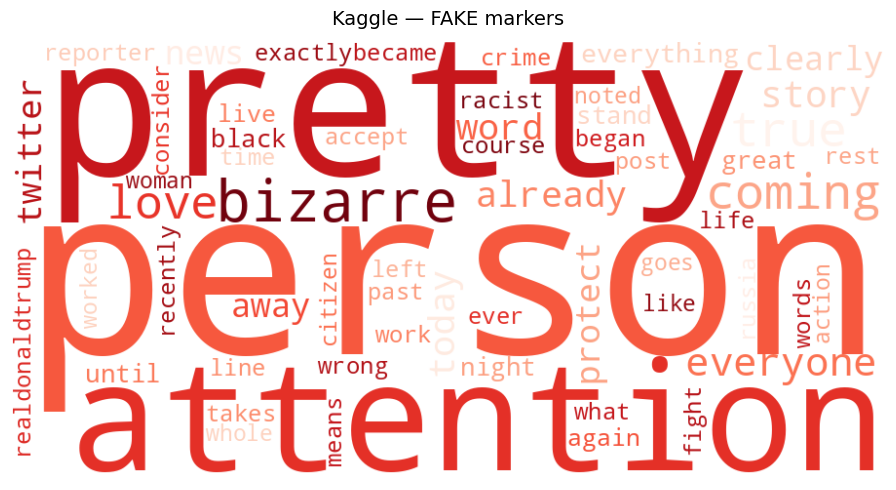

Saved: shap_outputs/wc_kaggle_fake.png


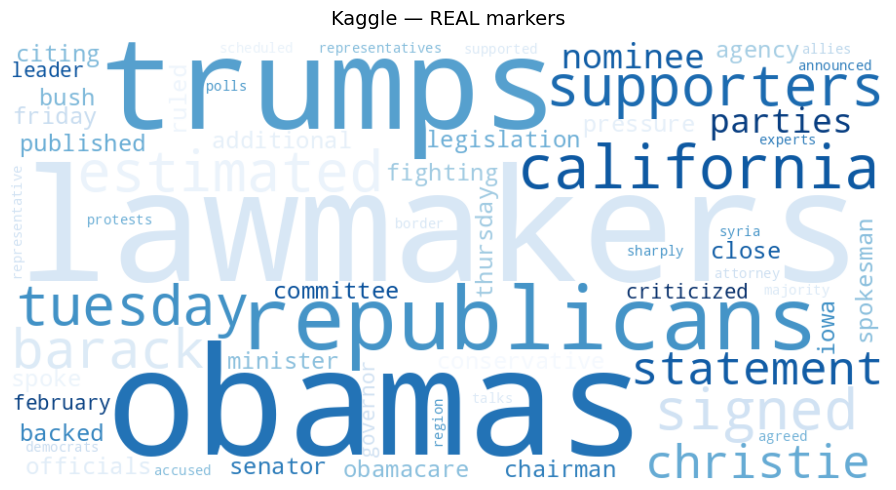

Saved: shap_outputs/wc_kaggle_real.png


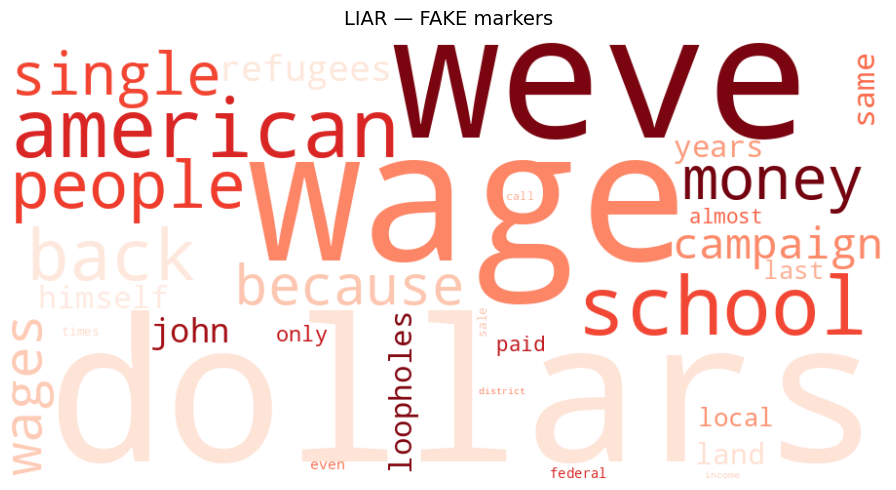

Saved: shap_outputs/wc_liar_fake.png


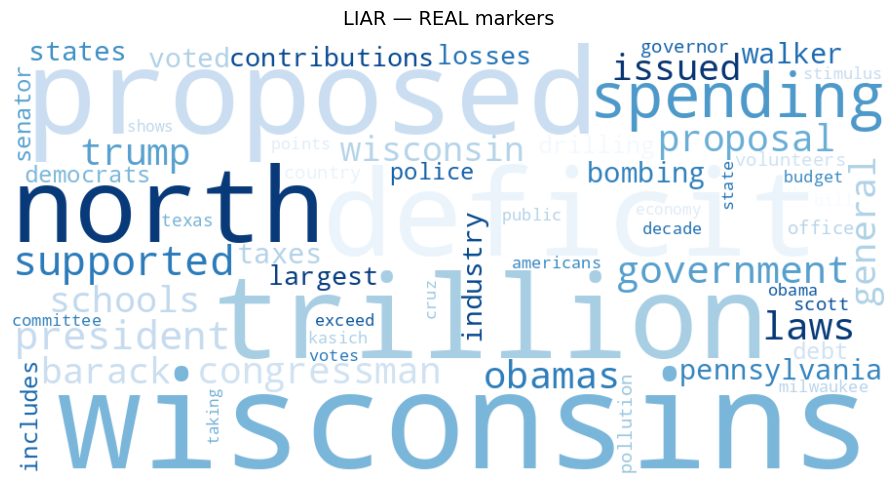

Saved: shap_outputs/wc_liar_real.png


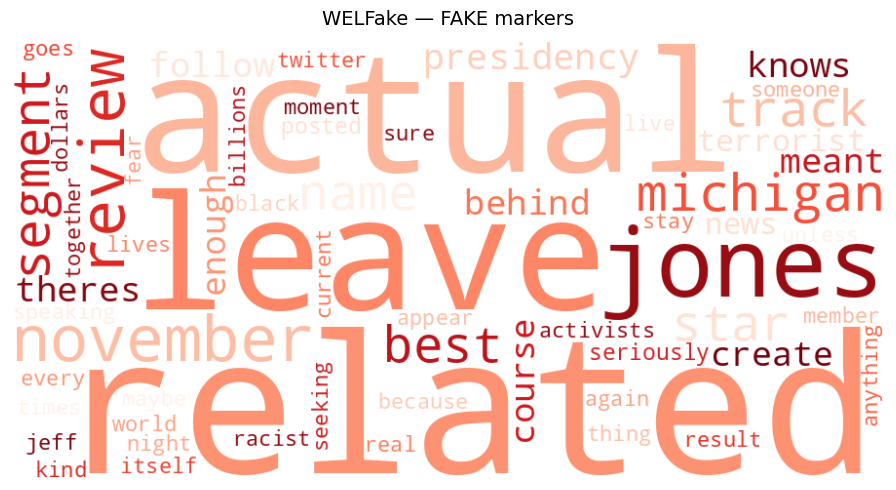

Saved: shap_outputs/wc_welfake_fake.png


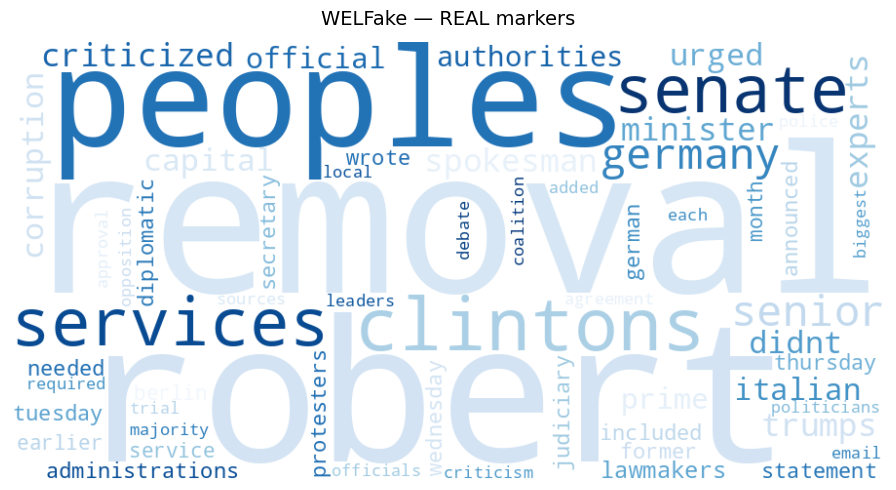

Saved: shap_outputs/wc_welfake_real.png


In [ ]:
def plot_wordcloud(word_avg, title, filename, fake=True):
    freq = {w: abs(s) for w, s in word_avg.items()
            if (s > 0 if fake else s < 0) and is_valid_word(w)}
    if not freq:
        print(f"No words for: {title}"); return

    wc = WordCloud(
        width=900, height=450, background_color="white",
        colormap="Reds" if fake else "Blues",
        max_words=60, prefer_horizontal=0.9, min_font_size=10
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(11, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.savefig(f"shap_outputs/{filename}", dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: shap_outputs/{filename}")


plot_wordcloud(kg_word_avg, "Kaggle — FAKE markers",   "wc_kaggle_fake.png",  True)
plot_wordcloud(kg_word_avg, "Kaggle — REAL markers",   "wc_kaggle_real.png",  False)
plot_wordcloud(li_word_avg, "LIAR — FAKE markers",     "wc_liar_fake.png",    True)
plot_wordcloud(li_word_avg, "LIAR — REAL markers",     "wc_liar_real.png",    False)
plot_wordcloud(wf_word_avg, "WELFake — FAKE markers",  "wc_welfake_fake.png", True)
plot_wordcloud(wf_word_avg, "WELFake — REAL markers",  "wc_welfake_real.png", False)


## 14. Cross-dataset heatmap

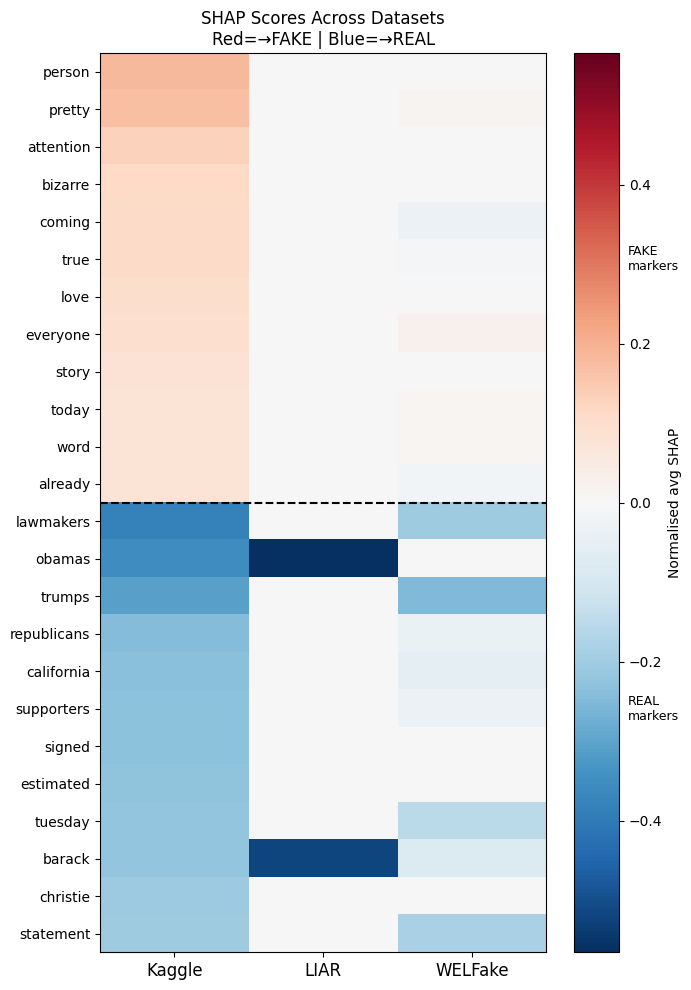

Saved: shap_outputs/cross_dataset_heatmap.png


In [ ]:
anchor_words = ([w for w,s in kg_top_fake[:12]] +
                [w for w,s in kg_top_real[:12]])

hmap   = np.array([[kg_word_avg.get(w,0), li_word_avg.get(w,0),
                    wf_word_avg.get(w,0)] for w in anchor_words])
maxval = max(abs(hmap.min()), abs(hmap.max())) or 0.01

fig, ax = plt.subplots(figsize=(7, 10))
im = ax.imshow(hmap, cmap="RdBu_r", aspect="auto", vmin=-maxval, vmax=maxval)
ax.set_xticks([0,1,2])
ax.set_xticklabels(["Kaggle","LIAR","WELFake"], fontsize=12)
ax.set_yticks(range(len(anchor_words)))
ax.set_yticklabels(anchor_words, fontsize=10)
ax.axhline(11.5, color="black", linewidth=1.5, linestyle="--")
ax.set_title("SHAP Scores Across Datasets\nRed=→FAKE | Blue=→REAL", fontsize=12)
ax.text(3.05,  5, "FAKE\nmarkers", fontsize=9, va="center")
ax.text(3.05, 17, "REAL\nmarkers", fontsize=9, va="center")
plt.colorbar(im, ax=ax, label="Normalised avg SHAP")
plt.tight_layout()
plt.savefig("shap_outputs/cross_dataset_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: shap_outputs/cross_dataset_heatmap.png")


## 15. Correct vs incorrect prediction analysis

In [ ]:
def analyse_correctness(shap_values, labels, dataset_name):
    correct_fake, correct_real = [], []
    wrong_as_fake, wrong_as_real = [], []

    for i, (sv, true_lbl) in enumerate(zip(shap_values, labels)):
        text  = " ".join(list(sv.data))
        probs = predict_proba([text])[0]
        pred  = 1 if probs[1] > 0.5 else 0
        if   true_lbl==1 and pred==1: correct_fake.append(i)
        elif true_lbl==0 and pred==0: correct_real.append(i)
        elif true_lbl==0 and pred==1: wrong_as_fake.append(i)
        elif true_lbl==1 and pred==0: wrong_as_real.append(i)

    total = len(labels)
    print(f"\n{'='*55}\n  {dataset_name}\n{'='*55}")
    print(f"  ✅ Correctly → FAKE : {len(correct_fake):3d} ({100*len(correct_fake)/total:.1f}%)")
    print(f"  ✅ Correctly → REAL : {len(correct_real):3d} ({100*len(correct_real)/total:.1f}%)")
    print(f"  ❌ Real→FAKE (FP)   : {len(wrong_as_fake):3d} ({100*len(wrong_as_fake)/total:.1f}%)")
    print(f"  ❌ Fake→REAL (FN)   : {len(wrong_as_real):3d} ({100*len(wrong_as_real)/total:.1f}%)")

    def top_confusing_words(indices, toward_fake=True):
        combined = defaultdict(float)
        for idx in indices:
            sv   = shap_values[idx]
            vals = sv.values[:, 1] if sv.values.ndim > 1 else sv.values
            seen = set()
            for w, v in zip(sv.data, vals):
                wc = clean_word(w).lower()
                if not is_valid_word(wc) or wc in seen: continue
                seen.add(wc)
                if toward_fake and float(v) > 0:  combined[wc] += float(v)
                elif not toward_fake and float(v) < 0: combined[wc] += abs(float(v))
        return sorted(combined.items(), key=lambda x: x[1], reverse=True)[:8]

    if wrong_as_fake:
        print(f"\n  Words that confused REAL→FAKE:")
        for w, s in top_confusing_words(wrong_as_fake, toward_fake=True):
            print(f"    🔴 {w:<20} {s:+.4f}")
    if wrong_as_real:
        print(f"\n  Words that confused FAKE→REAL:")
        for w, s in top_confusing_words(wrong_as_real, toward_fake=False):
            print(f"    🔵 {w:<20} {s:+.4f}")

    return correct_fake, correct_real, wrong_as_fake, wrong_as_real


kg_cf, kg_cr, kg_wf, kg_wr = analyse_correctness(shap_values_kg, kg_labels, "Kaggle")
li_cf, li_cr, li_wf, li_wr = analyse_correctness(shap_values_li, li_labels, "LIAR")
wf_cf, wf_cr, wf_wf, wf_wr = analyse_correctness(shap_values_wf, wf_labels, "WELFake")



  Kaggle
  ✅ Correctly → FAKE :  50 (50.0%)
  ✅ Correctly → REAL :  50 (50.0%)
  ❌ Real→FAKE (FP)   :   0 (0.0%)
  ❌ Fake→REAL (FN)   :   0 (0.0%)

  LIAR
  ✅ Correctly → FAKE :  24 (24.0%)
  ✅ Correctly → REAL :  30 (30.0%)
  ❌ Real→FAKE (FP)   :  20 (20.0%)
  ❌ Fake→REAL (FN)   :  26 (26.0%)

  Words that confused REAL→FAKE:
    🔴 god-knows-who-else   +0.0851
    🔴 book                 +0.0754
    🔴 florida              +0.0583
    🔴 school               +0.0472
    🔴 turned               +0.0433
    🔴 havent               +0.0411
    🔴 list                 +0.0399
    🔴 david                +0.0397

  Words that confused FAKE→REAL:
    🔵 barack               +0.5410
    🔵 president            +0.5065
    🔵 spending             +0.3757
    🔵 menendez             +0.3743
    🔵 obamacare            +0.3681
    🔵 voted                +0.3617
    🔵 wisconsins           +0.3262
    🔵 obamas               +0.3205

  WELFake
  ✅ Correctly → FAKE :   7 (7.0%)
  ✅ Correctly → REAL :   6 (6.0

## 16. Sentiment analysis

Running sentiment analysis...

Kaggle:
  Polarity    — Fake:0.1154  Real:0.0908  (Fake is 1.27x more emotional)
  Subjectivity— Fake:0.4689  Real:0.3566  (Fake is 1.31x more subjective)

LIAR:
  Polarity    — Fake:0.1533  Real:0.1493  (Fake is 1.03x more emotional)
  Subjectivity— Fake:0.2964  Real:0.2630  (Fake is 1.13x more subjective)

WELFake:
  Polarity    — Fake:0.0921  Real:0.1420  (Fake is 0.65x more emotional)
  Subjectivity— Fake:0.3428  Real:0.4264  (Fake is 0.80x more subjective)


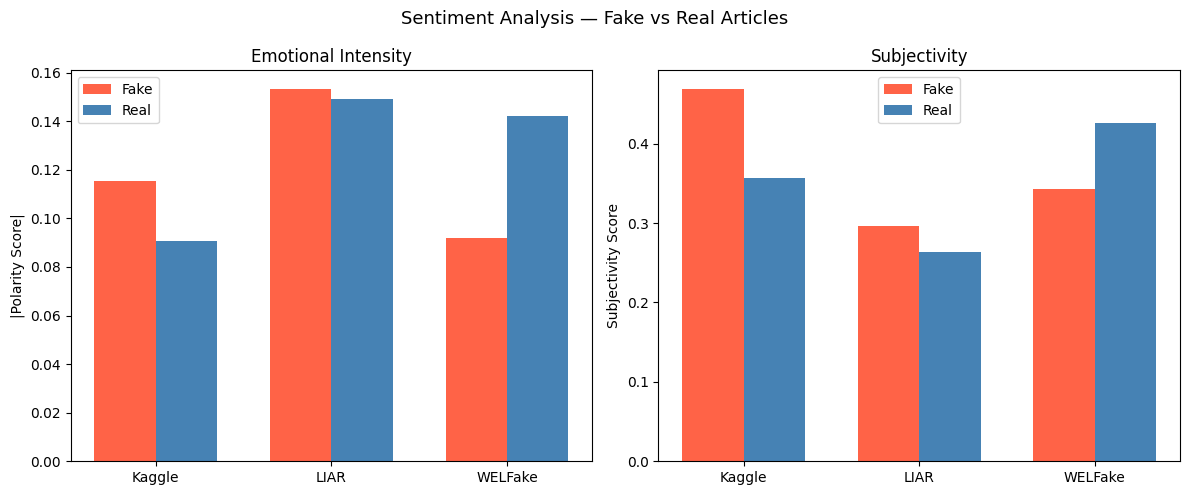

Saved: shap_outputs/sentiment_analysis.png


In [ ]:
def analyse_sentiment(texts, labels, dataset_name):
    fake_pol, real_pol = [], []
    fake_subj, real_subj = [], []
    for text, label in zip(texts, labels):
        blob = TextBlob(text[:1000])
        p, s = abs(blob.sentiment.polarity), blob.sentiment.subjectivity
        if label==1: fake_pol.append(p); fake_subj.append(s)
        else:        real_pol.append(p); real_subj.append(s)

    fp = np.mean(fake_pol); rp = np.mean(real_pol)
    fs = np.mean(fake_subj); rs = np.mean(real_subj)

    print(f"\n{dataset_name}:")
    print(f"  Polarity    — Fake:{fp:.4f}  Real:{rp:.4f}  "
          f"(Fake is {fp/rp:.2f}x more emotional)")
    print(f"  Subjectivity— Fake:{fs:.4f}  Real:{rs:.4f}  "
          f"(Fake is {fs/rs:.2f}x more subjective)")
    return {"dataset":dataset_name,
            "fake_polarity":round(fp,4), "real_polarity":round(rp,4),
            "fake_subjectivity":round(fs,4), "real_subjectivity":round(rs,4)}


print("Running sentiment analysis...")
sent_kg = analyse_sentiment(kg_texts, kg_labels, "Kaggle")
sent_li = analyse_sentiment(li_texts, li_labels, "LIAR")
sent_wf = analyse_sentiment(wf_texts, wf_labels, "WELFake")

datasets_s = ["Kaggle","LIAR","WELFake"]
fake_pol   = [sent_kg["fake_polarity"],     sent_li["fake_polarity"],    sent_wf["fake_polarity"]]
real_pol   = [sent_kg["real_polarity"],     sent_li["real_polarity"],    sent_wf["real_polarity"]]
fake_subj  = [sent_kg["fake_subjectivity"], sent_li["fake_subjectivity"],sent_wf["fake_subjectivity"]]
real_subj  = [sent_kg["real_subjectivity"], sent_li["real_subjectivity"],sent_wf["real_subjectivity"]]

x = np.arange(3); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, fake_d, real_d, title, ylabel in [
    (axes[0], fake_pol,  real_pol,  "Emotional Intensity",   "|Polarity Score|"),
    (axes[1], fake_subj, real_subj, "Subjectivity",          "Subjectivity Score"),
]:
    ax.bar(x-w/2, fake_d, w, label="Fake", color="tomato")
    ax.bar(x+w/2, real_d, w, label="Real", color="steelblue")
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(datasets_s)
    ax.set_ylabel(ylabel); ax.legend()
plt.suptitle("Sentiment Analysis — Fake vs Real Articles", fontsize=13)
plt.tight_layout()
plt.savefig("shap_outputs/sentiment_analysis.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: shap_outputs/sentiment_analysis.png")


## 17. Consistent markers across all 3 datasets

In [ ]:
all_fake = (set(w for w,s in kg_top_fake[:20]) &
            set(w for w,s in li_top_fake[:20]) &
            set(w for w,s in wf_top_fake[:20]))

all_real = (set(w for w,s in kg_top_real[:20]) &
            set(w for w,s in li_top_real[:20]) &
            set(w for w,s in wf_top_real[:20]))

print("="*60)
print("CONSISTENT FAKE MARKERS (all 3 datasets top 20):")
print("="*60)
if all_fake:
    for w in sorted(all_fake):
        print(f"  🔴 {w:<20} "
              f"Kaggle:{kg_word_avg.get(w,0):+.4f}  "
              f"LIAR:{li_word_avg.get(w,0):+.4f}  "
              f"WELFake:{wf_word_avg.get(w,0):+.4f}")
else:
    print("  None — datasets have domain-specific fake markers")
    print("  (This IS a finding: fake news patterns differ by domain)")

print("\n" + "="*60)
print("CONSISTENT REAL MARKERS (all 3 datasets top 20):")
print("="*60)
if all_real:
    for w in sorted(all_real):
        print(f"  🔵 {w:<20} "
              f"Kaggle:{kg_word_avg.get(w,0):+.4f}  "
              f"LIAR:{li_word_avg.get(w,0):+.4f}  "
              f"WELFake:{wf_word_avg.get(w,0):+.4f}")
else:
    print("  None — real markers also partially domain-specific")


CONSISTENT FAKE MARKERS (all 3 datasets top 20):
  None — datasets have domain-specific fake markers
  (This IS a finding: fake news patterns differ by domain)

CONSISTENT REAL MARKERS (all 3 datasets top 20):
  None — real markers also partially domain-specific
